В этой части получаем графики зависимости фазы сгенерированной от отклонения между полученной фазой и сгенерированной. Это делается для того чтобы определить насколько точно работают методы во всём возможном диапазоне. Графики строятся для разных частот сигнала. Таким образом получается оценить точность методов для разных фаз и частот сгенерированных сигналов

In [1]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.path.join(os.getcwd(), ".."))

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

from model.relevant_methods import phase_methods

c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Phase_methods_analytics\Local_analysis\..


In [2]:
import numpy as np

def get_phase_lockin(time, sig1, sig2, f0, n_periods=10):
    """
    Разность фаз между двумя сигналами методом lock-in (классическая реализация).

    Параметры:
    ----------
    time : array
        Временная ось
    sig1, sig2 : array
        Сигналы одинаковой длины
    f0 : float
        Опорная частота
    n_periods : int
        Размер окна в периодах

    Возвращает:
    -----------
    phase_diff : float
        Разность фаз (в градусах)
    """

    # частота дискретизации
    fs = 1.0 / np.mean(np.diff(time))

    # размер окна
    samples_per_period = fs / f0
    window_size = int(round(samples_per_period * n_periods))

    if window_size >= len(sig1):
        window_size = len(sig1) // 2

    # --- комплексная опора (ключевой момент!)
    ref = np.exp(-1j * 2 * np.pi * f0 * time)

    # --- демодуляция
    demod1 = sig1 * ref
    demod2 = sig2 * ref

    # --- окно (лучше чем прямоугольное)
    window = np.hanning(window_size)
    window /= np.sum(window)

    # --- НЧ фильтрация
    C1 = np.convolve(demod1, window, mode="same")
    C2 = np.convolve(demod2, window, mode="same")

    # --- фазовая разность (инвариантна к фазе опоры!)
    phase_diff_t = np.angle(C2 * np.conj(C1))

    # --- агрегирование (устойчивее, чем KDE для такой задачи)
    phase_diff = np.angle(np.mean(np.exp(1j * phase_diff_t)))

    return np.rad2deg(phase_diff)

In [3]:
def variate_phase(phase_method, F=444e3, duration_T=300, fs_mult=20, gen_unstable=1, bits=12):
    phases_x = []
    errors_z = []

    for p_deg in tqdm(range(1, 180, 1), desc=f"Метод {phase_method.__name__}"):
        duration = duration_T / F
        fs = F * fs_mult
        t = np.linspace(0, duration, int(duration * fs))
        
        # Генерируем массив фазы (сигнал)
        phase_signal = md.generate_common_phase(t, F, gen_unstable, phase0_deg=0)
        
        # Генерируем сигналы, используя p_deg (число)
        U, I = md.generate_signals_from_phase(phase_signal, phase_diff_deg=p_deg)
        
        U = md.adc_quantize(U, int(bits), 1)
        I = md.adc_quantize(I, int(bits), 1)
        
        # Измеряем фазу методом
        phase_mes = phase_method(t, U, I, F)
        
        # Считаем чистую ошибку: разница между измеренным и эталонным p_deg
        error = abs(abs(phase_mes) - abs(p_deg))

        phases_x.append(p_deg)
        errors_z.append(error)

    return phases_x, errors_z


In [4]:
def plot_for_one_F(phase_methods,phases_arrays,phase_diff_arrays, title=""):
    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(2, 1)
    front = 12

    ax1 = fig.add_subplot(gs[0, 0])
    for i, method in enumerate(phase_methods):
        label_name = method.__name__.replace("get_phase_", "")
        ax1.plot(
            phases_arrays[i],
            np.abs(phase_diff_arrays[i]),
            label=label_name,
            linewidth=2
        )

    ax1.set_xlabel('Phase shift, °', fontsize=front)
    ax1.set_ylabel('Phase measurement deviation, °', fontsize=front)
    ax1.tick_params(axis='both', labelsize=front)
    ax1.grid(True)
    ax1.legend(fontsize=10)

    ax1.set_yscale('log')

    ax1.set_title(title, fontsize=front + 2)
    plt.tight_layout()
    plt.show()

In [5]:
F=440
phases_arrays, phase_diff_arrays = variate_phase(md.get_phase_LI,F=F)

Метод get_phase_LI: 100%|██████████| 179/179 [00:33<00:00,  5.32it/s]


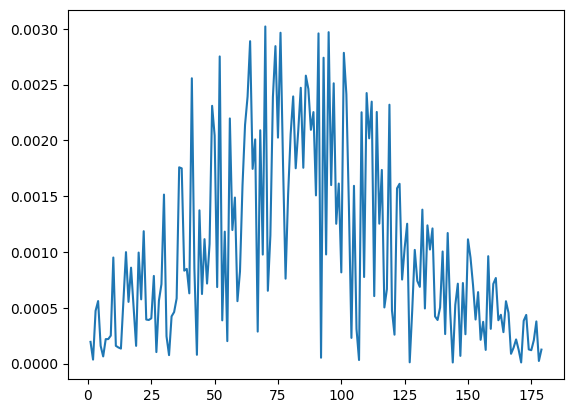

In [6]:
plt.plot(phases_arrays, phase_diff_arrays)